# 用PROC KRIGE2D对医疗服务范围内急诊等待时间进行空间预测

## 摘要

一个医疗系统网络运营团队测量了大都市服务范围内每个有人值守机构的平均急诊(ED)等待时间(分钟),希望得到一个连续的等待时间曲面,以发现服务不足的空白区域,用于新建紧急护理点选址。本笔记本生成了一组合成的**90个地理编码机构**,拟合了一个带块金效应的**普通克里金**模型,并在覆盖50公里 x 50公里服务范围的规则网格上对急诊等待时间进行插值,在每个网格节点和三个候选紧急护理选址处给出点预测值和克里金标准误。

在这90家机构中,观测到的等待时间平均为**35.5分钟**(范围7.5至58.7)。克里金曲面几乎精确地再现了这一中心值(网格节点均值**35.55分钟**),范围从东南方安静区域的**16.1**到西北方拥堵区域的**56.4**,预测等待热点集中在市中心高峰附近。在三个候选紧急护理选址中,最靠近市中心核心区的一个预测等待时间最高(**52.2 +/- 7.3分钟**),是最有力的循证选址案例。

## 数据来源

所有数据均为合成数据,在第一个DATA步骤中内联生成(`call streaminit(20260531)`)。未使用任何外部或网络文件。

| 数据集 | 行数 | 变量 | 类型 | 描述 |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | 数值 | 机构在大都市服务范围网格内的东坐标(公里,0-50) |
| `ed_sites` | 90 | `north` | 数值 | 机构在大都市服务范围网格内的北坐标(公里,0-50) |
| `ed_sites` | 90 | `site_id` | 字符 | 机构标识符(如 `FAC037`) |
| `ed_sites` | 90 | `wait_min` | 数值 | 观测到的平均急诊等待时间(分钟);由西北-东南拥堵梯度、市中心高峰和局部噪声组合而成的空间相关曲面 |

## 用PROC KRIGE2D对急诊等待时间进行空间预测

一个区域医疗系统在**50公里 x 50公里**的大都市服务范围内分布着多个**急诊科和紧急护理诊所**。每个机构都上报其**平均急诊等待时间**(分钟)。等待时间存在空间相关性: 拥堵的西北城区较高,而外围的东南机构较低。网络规划部门希望得到一个带不确定性的*连续*等待时间曲面,以识别新建紧急护理点能最大程度缓解压力的空白区域。

**PROC KRIGE2D** 执行二维普通克里金插值: 它使用半变异函数模型将测得的等待时间插值到网格位置上,在每个节点返回预测值和克里金标准误。我们将:

1. 生成一个真实的合成机构数据集。
2. 刻画观测到的等待时间分布。
3. 用带块金效应的球面模型进行克里金插值并检查曲面。
4. 直接在三个候选紧急护理选址处进行预测。

## 步骤1 - 生成合成机构数据

我们在服务范围内均匀散布90家机构。底层的"真实"等待曲面结合了一个平滑的大尺度趋势(西北向东南的拥堵梯度,加上(15, 38)附近的市中心隆起)和一个平滑的区域性涡旋,因此该场是真正具有空间自相关性的,而非纯粹的噪声。我们加入了少量测量块金效应,以模拟日常上报的波动。

In [1]:
数据 ed_sites;
   调用 streaminit(20260531);
   长度 site_id $6;
   循环 i = 1 到 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* 大尺度拥堵趋势: 西北市中心核心区较高,
         向东南郊区边缘逐渐降低 */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* 以(15, 38)附近为中心的市中心高峰 */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* 平滑的区域性涡旋,制造真实的空间自相关 */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* 局部上报噪声(测量块金效应) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      如果 wait_min < 3 那么 wait_min = 3;

      site_id = cats('FAC', PUT(i, z3.));
      输出;
   结束;
   保留 site_id east north wait_min;
运行;

过程 打印 数据=ed_sites(obs=10) noobs 标签;
   标题 "合成急诊机构前10家(公里坐标,等待时间以分钟计)";
   标签 site_id="机构编号" east="东坐标(公里)" north="北坐标(公里)" wait_min="等待时间(分钟)";
   变量 site_id east north wait_min;
运行;

                                               合成急诊机构前10家(公里坐标,等待时间以分钟计)                                                

        机构编号            东坐标(公里)            北坐标(公里)              等待时间(分钟)
FAC001            42.1064239035      44.8746335392                  36.7
FAC002            10.6189061789      14.5101311244                  36.2
FAC003            48.9064287162        18.61727984                  17.7
FAC004             45.555283186       43.264675772                  34.5
FAC005            32.9816533373      24.7120124541                  32.5
FAC006            31.1796232687      19.1168441231                  31.4
FAC007            34.6664652019      35.2149577448                  39.2
FAC008            40.5104234712       2.9588781811                  17.1
FAC009             9.9213354522      40.5368804705                  54.3
FAC010            24.5041747799      22.5897811072                  35.9

... 80 more observations (showing 10 of 90)




NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## 步骤2 - 刻画观测到的等待时间

在进行克里金插值之前,先确认曲面的分布是否合理。快速的 `PROC MEANS` 汇总给出了范围和集中趋势,克里金曲面应重现这些特征。这90家机构的等待时间平均为**35.5分钟**,标准差为**10.6**,范围从最安静的郊区机构**7.5**到最拥堵的市中心机构**58.7** - 对于插值目标来说,这是一个宽泛而真实的分布。

In [2]:
过程 均值 数据=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   标题 "各机构观测到的急诊等待时间分布";
   标签 wait_min="等待时间(分钟)";
   变量 wait_min;
运行;

                                                    各机构观测到的急诊等待时间分布                                                     

                                                  The MEANS Procedure

 Variable  Label                       N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -------------------------------------------------------------------------------------------------------------------------------------
 wait_min  等待时间(分钟)                   90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 -------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 步骤3 - 带球面模型的普通克里金插值

`COORDINATES` 语句指定空间坐标轴,`PREDICT VAR=` 指定分析变量并设定搜索邻域,`MODEL` 提供半变异函数。我们使用**球面**形式(当相关性在有限距离处衰减为零时的标准选择),参数为:

- `SCALE=120` - 偏基台值(空间结构解释的方差),
- `RANGE=18` - 相关性在约18公里处降至背景水平,
- `NUGGET=14` - 零距离处的测量/上报不连续性。

我们在覆盖整个服务范围的规则**9 x 9 = 81节点**网格上进行插值(`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`) - 粗到足以直接汇总和排序每个节点,细到足以刻画结构。`OUTEST=` 捕获网格化的预测值和标准误;`OUTNBHD=` 记录每次局部求解纳入了多少家机构。`PLOTS=` 请求观测数据地图和按标准误填色的预测等高线图。

                                                    各机构观测到的急诊等待时间分布                                                     

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


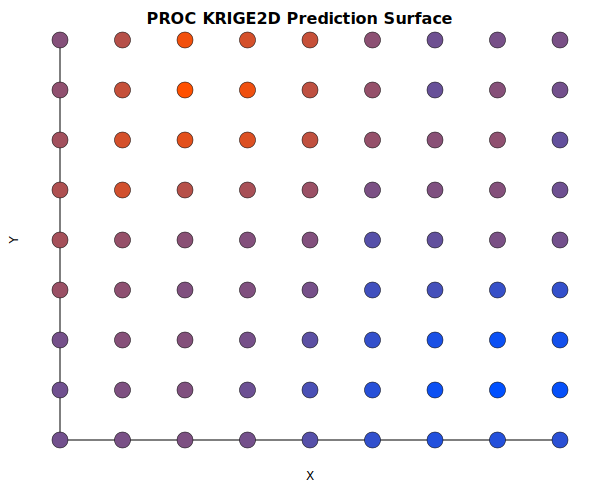

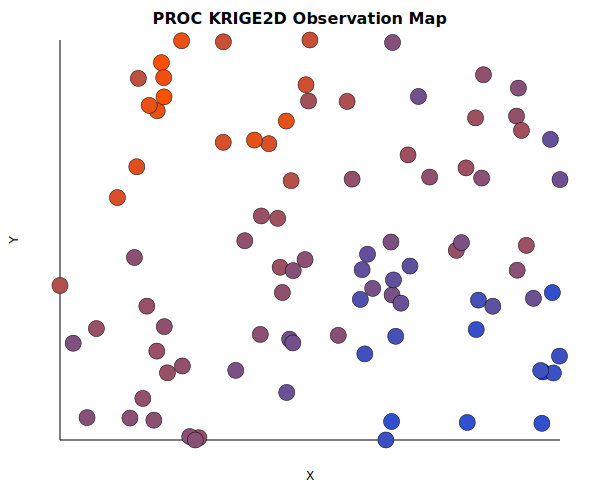

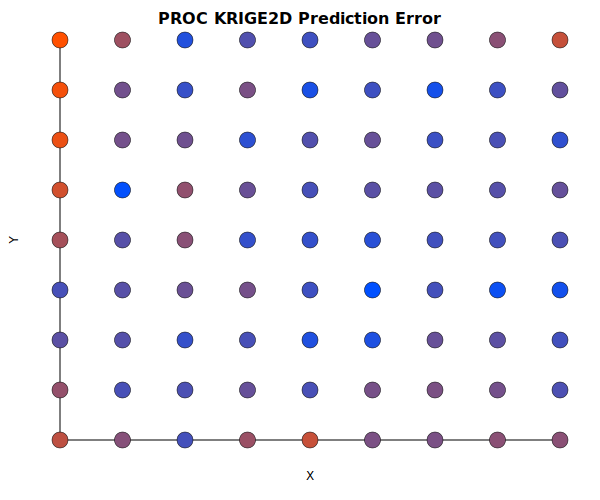

In [3]:
过程 krige2d 数据=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   标题 "急诊等待时间普通克里金插值 - 球面模型";
   COORDINATES XC=east YC=north;
   predict 变量=wait_min radius=20 minpoints=10 maxpoints=40;
   模型 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 到 50 按照 6 y=0 到 50 按照 6;
运行;

## 步骤4 - 检查克里金曲面

`OUTEST=` 数据集每个网格节点一行,包含预测的等待时间(`estimate`)及其克里金标准误(`stderr`)。我们汇总曲面并标记预测值最高的节点 - 即新建紧急护理点能最大程度缓解压力的候选区域。

克里金曲面均值(**35.55分钟**)几乎精确地跟踪观测到的机构平均值(35.5),这是普通克里金无偏性的一个合理性检验。预测值范围从东南稀疏区域的**16.1**到西北拥堵区域的**56.4**;标准误在机构密集处为**5.1**,在采样稀疏的角落为**11.2**。六个预测值最高的节点全部位于西北象限,坐标约在(12-18, 36-48)附近,正好落在数据中内置的市中心高峰上。

In [4]:
过程 均值 数据=krige_sph n mean MIN MAX maxdec=2;
   标题 "克里金曲面摘要(预测等待分钟数与标准误)";
   标签 estimate="预测等待时间(分钟)" stderr="标准误";
   变量 estimate stderr;
运行;

过程 排序 数据=krige_sph out=hot_nodes;
   按照 DESCENDING estimate;
运行;

过程 打印 数据=hot_nodes(obs=6) noobs 标签;
   标题 "预测急诊等待时间最高的六个网格节点";
   标签 x="X坐标" y="Y坐标" estimate="预测等待时间(分钟)" stderr="标准误";
   变量 x y estimate stderr;
运行;

                                                  克里金曲面摘要(预测等待分钟数与标准误)                                                  

                                                  The MEANS Procedure

 Variable  Label                             N        Mean     Minimum     Maximum
 ---------------------------------------------------------------------------------
 ESTIMATE  预测等待时间(分钟)                       81       35.55       16.07       56.38
 STDERR    标准误                              81        7.38        5.06       11.20
 ---------------------------------------------------------------------------------

                                                   预测急诊等待时间最高的六个网格节点                                                    

    X坐标      Y坐标                  预测等待时间(分钟)           标准误
     12       42               56.3838526129  6.3860887297
     12       48                54.379464215   5.876759721
     18       42                 53.81777091  8.0028060667
     12       36               51


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## 步骤5 - 在特定候选地点进行预测

网络规划部门提出了三个候选紧急护理选址。我们通过将每个候选点作为单节点网格提供(`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`),直接在该点进行克里金插值,给规划人员提供该确切坐标处的预测等待时间及其克里金标准误。

最靠近市中心核心区的候选点 **(14, 37)** 返回了最高的预测等待时间 - **52.2 +/- 7.3分钟** - 证实它将吸纳最繁忙急诊科的部分需求。东南候选点 **(32, 12)** 位于安静的郊区角落,为 **22.0 +/- 6.2**,东北候选点 **(42, 44)** 处于中等水平,为 **36.4 +/- 5.9**。仅从预测等待时间来看,市中心候选点是最有力的循证选址案例。

In [5]:
过程 krige2d 数据=ed_sites outest=cand_dt PLOTS=none;
   标题 "候选地点A - 市中心核心区(14, 37)";
   COORDINATES XC=east YC=north;
   predict 变量=wait_min radius=20 minpoints=8 maxpoints=40;
   模型 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 到 14 按照 1 y=37 到 37 按照 1;
运行;

过程 krige2d 数据=ed_sites outest=cand_se PLOTS=none;
   标题 "候选地点B - 东南郊区(32, 12)";
   COORDINATES XC=east YC=north;
   predict 变量=wait_min radius=20 minpoints=8 maxpoints=40;
   模型 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 到 32 按照 1 y=12 到 12 按照 1;
运行;

过程 krige2d 数据=ed_sites outest=cand_ne PLOTS=none;
   标题 "候选地点C - 东北边缘(42, 44)";
   COORDINATES XC=east YC=north;
   predict 变量=wait_min radius=20 minpoints=8 maxpoints=40;
   模型 FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 到 42 按照 1 y=44 到 44 按照 1;
运行;

数据 candidates;
   设置 cand_dt cand_se cand_ne;
运行;

过程 打印 数据=candidates noobs 标签;
   标题 "三个候选紧急护理选址的预测急诊等待时间";
   标签 x="X坐标" y="Y坐标" estimate="预测等待时间(分钟)" stderr="标准误";
   变量 x y estimate stderr;
运行;

                                                   预测急诊等待时间最高的六个网格节点                                                    

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                                                   预测急诊等待时间最高的六个网格节点                                                    

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## 结果解读

- **克里金曲面再现了服务范围的拥堵结构。** 球面普通克里金模型插值出一个平滑的等待时间场,其网格节点均值(35.55分钟)与观测到的机构平均值(35.5分钟)相符,最高的预测等待时间 - 最高达56.4分钟 - 集中在我们内置于合成数据中的、位于(15, 38)附近市中心高峰周围的西北象限。这种对应关系是模型行为正常的合理性检验。
- **标准误定位置信度。** 克里金标准误在机构密集处为5.1分钟,在采样稀疏的服务范围角落为11.2分钟。规划人员应谨慎对待`stderr`较高区域的预测值;这些区域也正是新增机构最能同时改善未来覆盖率和未来测量精度的地方。
- **点预测支持选址决策。** 直接对三个候选地点进行克里金插值,把曲面变成了一张可操作的表格。市中心候选点(14, 37)的预测等待时间最高(52.2分钟),标准误适中(7.3),是新建紧急护理点以分流最繁忙急诊科的最有力循证案例;东南郊区候选点(32, 12)位于低需求角落(22.0分钟),东北边缘候选点(42, 44)处于中等水平(36.4分钟)。

实际应用中,半变异函数参数(`SCALE`、`RANGE`、`NUGGET`)通常会用 PROC VARIOGRAM 经验估计,然后传给 KRIGE2D - 既可以像本例这样显式给出数值,也可以通过 `RESTORE` 从 VARIOGRAM item store 自动获取。